In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# preprocessing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PolynomialFeatures

# models build and train
from sklearn.linear_model import LinearRegression, Lasso, Ridge
from sklearn.pipeline import make_pipeline

# model validation and evaluation
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.model_selection import cross_val_score

In [5]:
data1 = pd.read_csv('data/advertising.csv')
print("size of data", data1.shape)
data1.head()

size of data (200, 5)


,Unnamed: 0,TV,Radio,Newspaper,Sales
0,1,230.1,37.8,69.2,22.1
1,2,44.5,39.3,45.1,10.4
2,3,17.2,45.9,69.3,9.3
3,4,151.5,41.3,58.5,18.5
4,5,180.8,10.8,58.4,12.9


In [8]:
data2 = data1.drop(columns=['Unnamed: 0'])
data2.describe()

,TV,Radio,Newspaper,Sales
count,200.000000,200.000000,200.000000,200.000000
mean,147.042500,23.264000,30.554000,14.022500
std,85.854236,14.846809,21.778621,5.217457
min,0.700000,0.000000,0.300000,1.600000
25%,74.375000,9.975000,12.750000,10.375000
50%,149.750000,22.900000,25.750000,12.900000
75%,218.825000,36.525000,45.100000,17.400000
max,296.400000,49.600000,114.000000,27.000000


In [9]:
data2.corr()

,TV,Radio,Newspaper,Sales
TV,1.000000,0.054809,0.056648,0.782224
Radio,0.054809,1.000000,0.354104,0.576223
Newspaper,0.056648,0.354104,1.000000,0.228299
Sales,0.782224,0.576223,0.228299,1.000000


<Axes: >

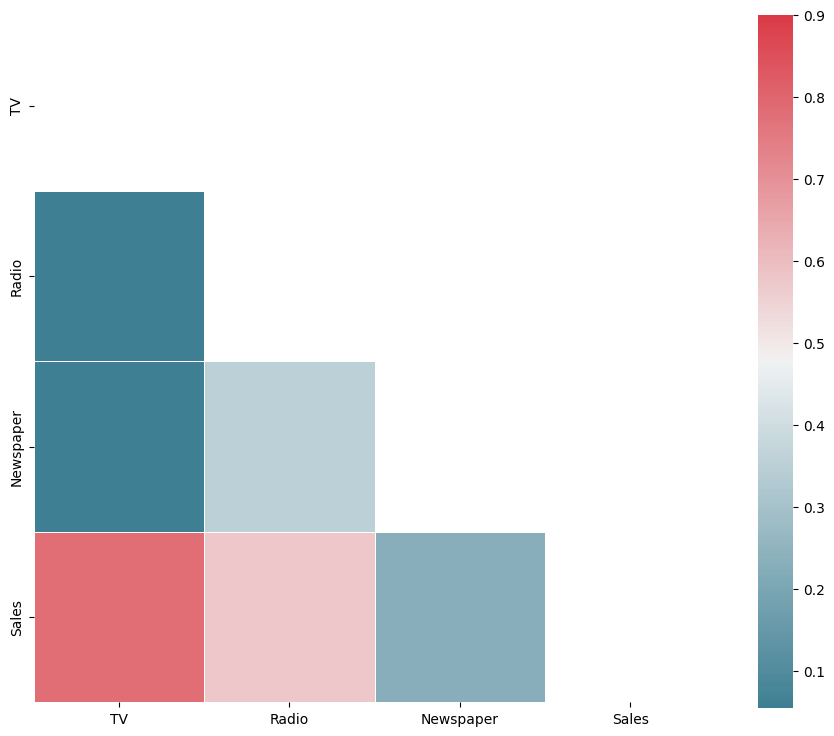

In [11]:

# Generate a mask for the upper triangle
mask = np.zeros_like(data2.corr(), dtype=np.bool)
mask[np.triu_indices_from(mask)] = True

# Set up the matplotlib figure
f, ax = plt.subplots(figsize=(11, 9))

# Generate a custom diverging colormap
cmap = sns.diverging_palette(220, 10, as_cmap=True)

# Draw the heatmap with the mask and correct aspect ratio
sns.heatmap(data2.corr(), mask=mask, cmap=cmap, vmax=.9, square=True, linewidths=.5, ax=ax)

Text(0.5, 1.0, 'Sales vs Newspaper')

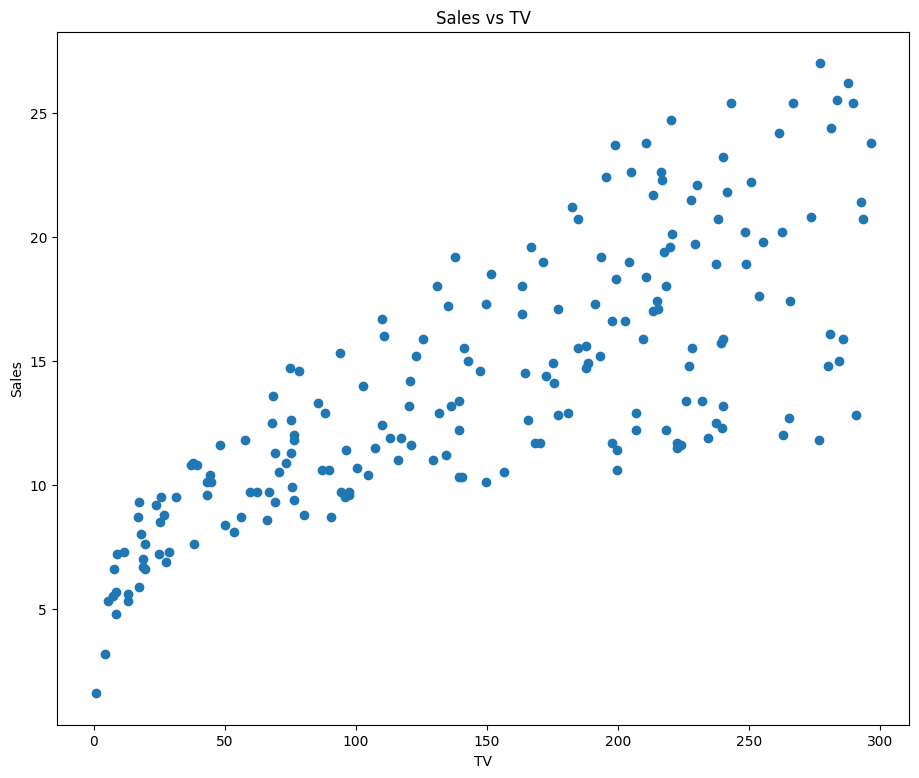

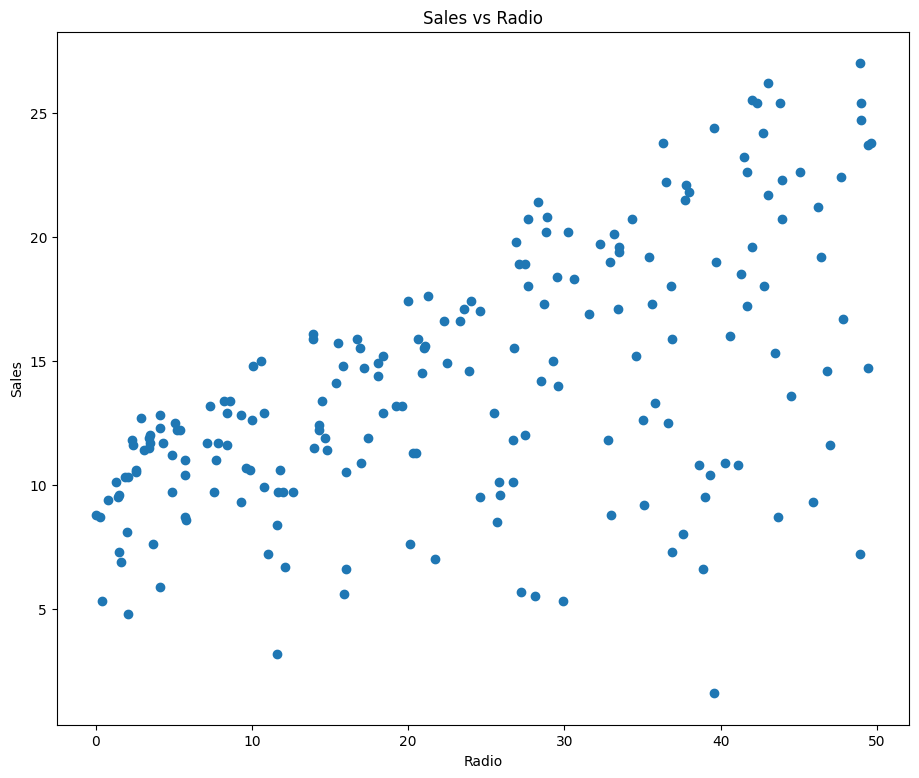

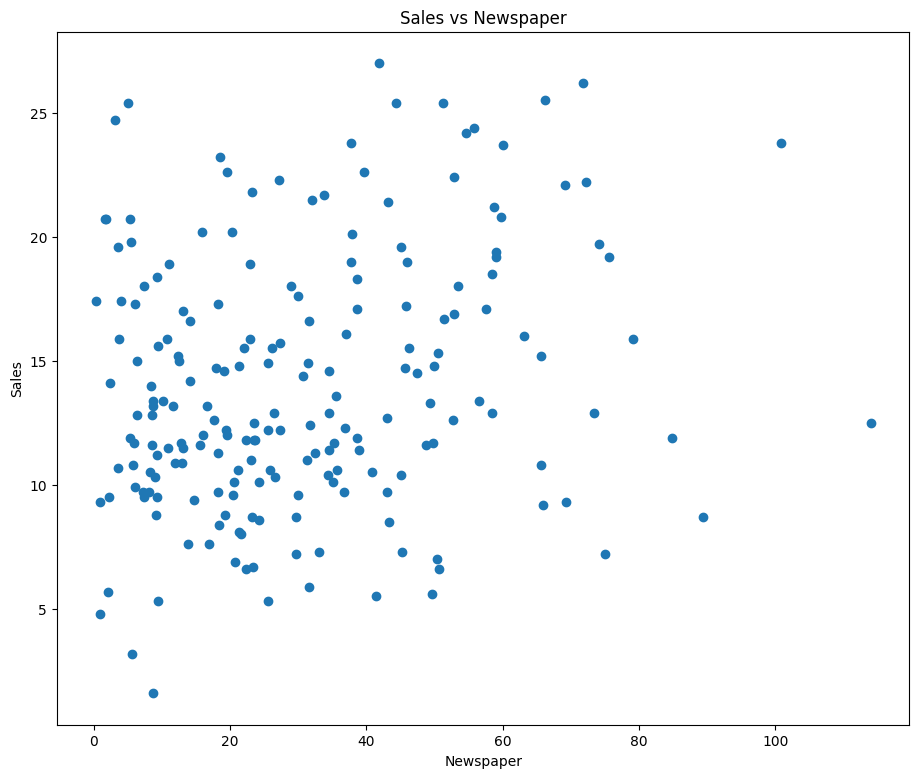

In [14]:
### Visualize the relationship using scatterplot

f, ax = plt.subplots(figsize=(11, 9))
plt.scatter(data2["TV"], data2["Sales"])
plt.xlabel("TV")
plt.ylabel("Sales")
plt.title("Sales vs TV")

f, ax = plt.subplots(figsize=(11, 9))
plt.scatter(data2["Radio"], data2["Sales"])
plt.xlabel("Radio")
plt.ylabel("Sales")
plt.title("Sales vs Radio")

f, ax = plt.subplots(figsize=(11, 9))
plt.scatter(data2["Newspaper"], data2["Sales"])
plt.xlabel("Newspaper")
plt.ylabel("Sales")
plt.title("Sales vs Newspaper")

Text(0.5, 1.0, 'Newspaper vs Radio')

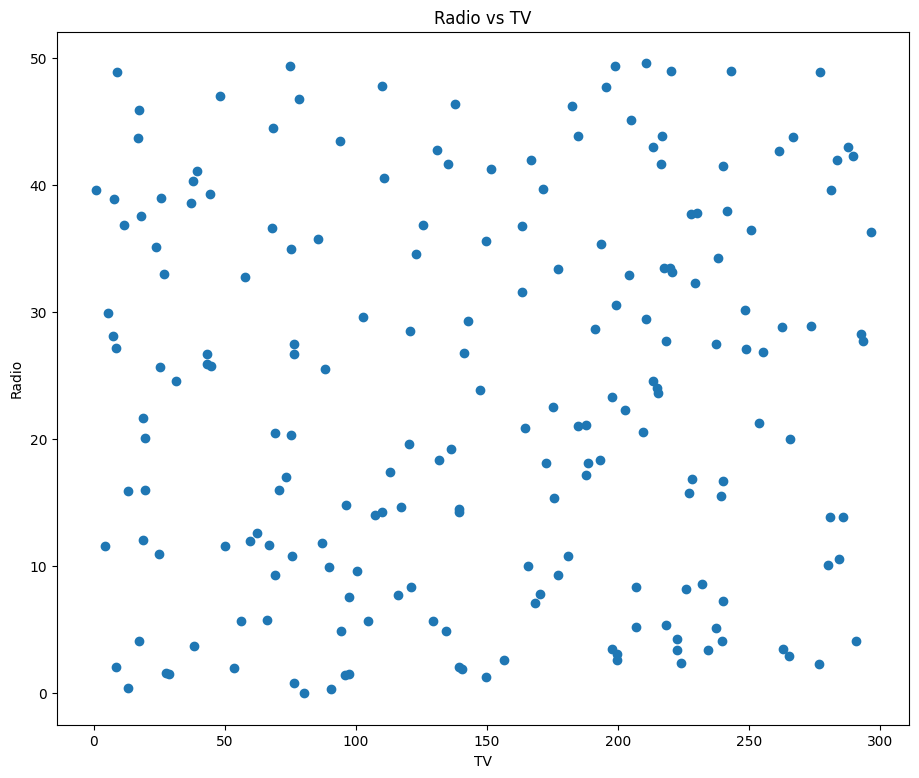

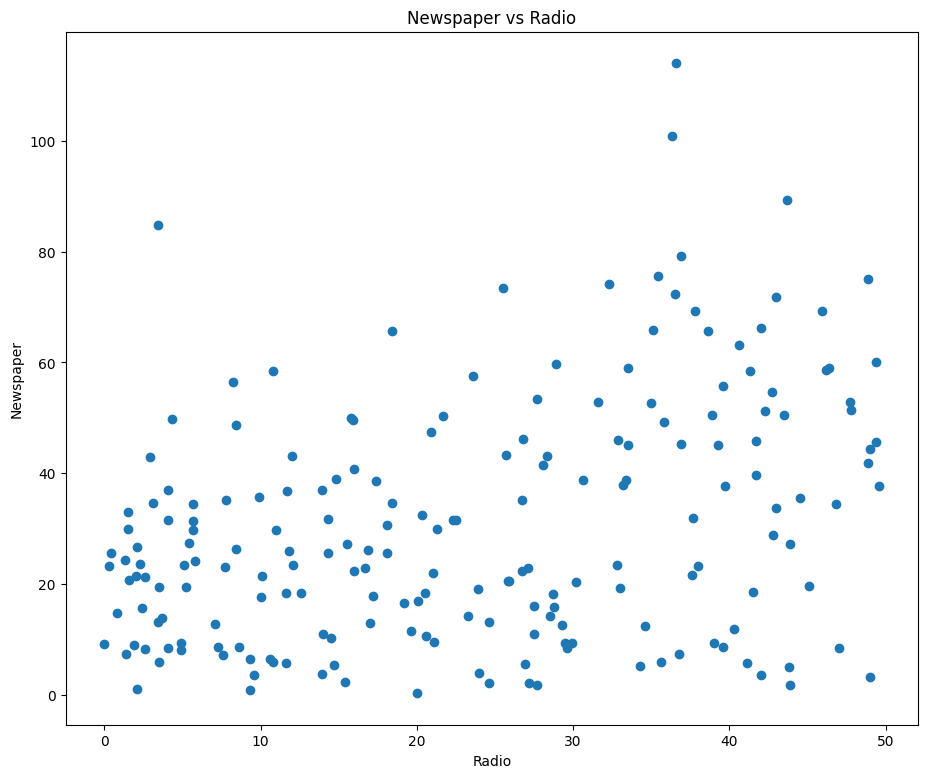

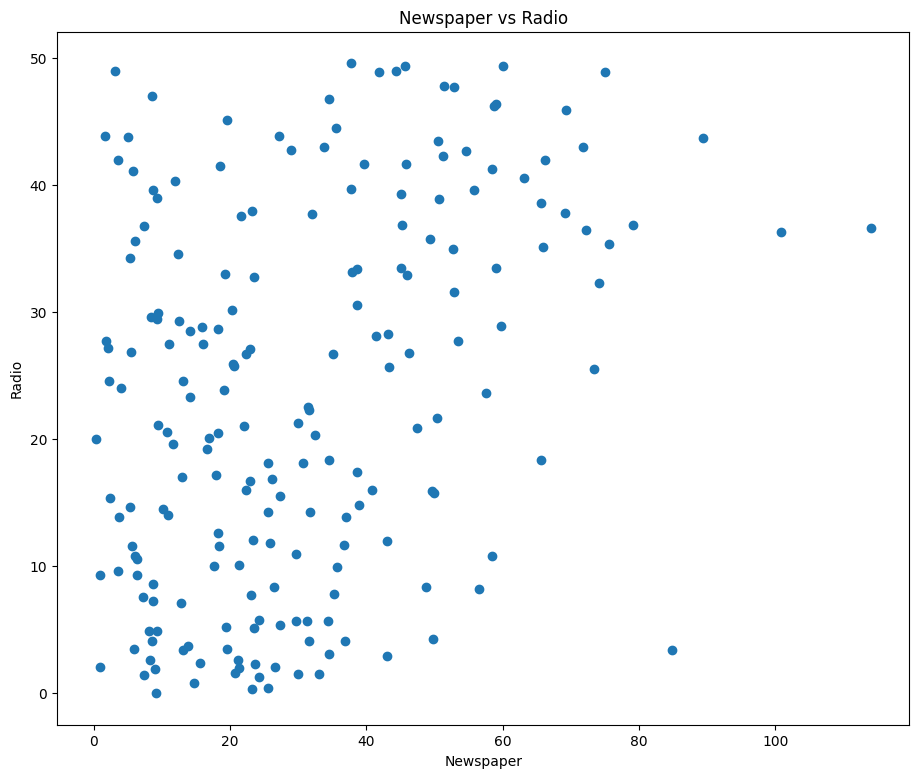

In [17]:
### Visualize the relationship using scatterplot

f, ax = plt.subplots(figsize=(11, 9))
plt.scatter(data2["TV"], data2["Radio"])
plt.xlabel("TV")
plt.ylabel("Radio")
plt.title("Radio vs TV")

f, ax = plt.subplots(figsize=(11, 9))
plt.scatter(data2["Radio"], data2["Newspaper"])
plt.xlabel("Radio")
plt.ylabel("Newspaper")
plt.title("Newspaper vs Radio")

f, ax = plt.subplots(figsize=(11, 9))
plt.scatter(data2["Newspaper"], data2["Radio"])
plt.xlabel("Newspaper")
plt.ylabel("Radio")
plt.title("Newspaper vs Radio")

### Data Preprocessing 

In [20]:
# seperating the features and target variable
X = data2.drop(columns=['Sales'], axis=1)
y = data2['Sales']

print("X shape", X.shape, "Data Overview", X.head(), "Data Type:", type(X))
print("y shape", y.shape, "Data Overview", X.head(), "Data Type:", type(y))

X shape (200, 3) Data Overview       TV  Radio  Newspaper
0  230.1   37.8       69.2
1   44.5   39.3       45.1
2   17.2   45.9       69.3
3  151.5   41.3       58.5
4  180.8   10.8       58.4 Data Type: <class 'pandas.core.frame.DataFrame'>
y shape (200,) Data Overview       TV  Radio  Newspaper
0  230.1   37.8       69.2
1   44.5   39.3       45.1
2   17.2   45.9       69.3
3  151.5   41.3       58.5
4  180.8   10.8       58.4 Data Type: <class 'pandas.core.series.Series'>


In [22]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state = 42)

print("X_train size:", X_train.shape)
print("y_train size:", y_train.shape)
print("\nx_test size:", X_test.shape)
print("y_test size:", y_test.shape)

X_train size: (150, 3)
y_train size: (150,)

x_test size: (50, 3)
y_test size: (50,)


In [25]:
data2.head()

,TV,Radio,Newspaper,Sales
0,230.1,37.8,69.2,22.1
1,44.5,39.3,45.1,10.4
2,17.2,45.9,69.3,9.3
3,151.5,41.3,58.5,18.5
4,180.8,10.8,58.4,12.9


In [24]:
# dataframe for storing results of metricies llike r2, mae, mse
metric_results = pd.DataFrame(columns=['PredictorModel/s', 'R2', 'MAE', 'MSE', 'RMSE', 'CrossValScore']) 
print("Metric Results DataFrame:\n", metric_results)

Metric Results DataFrame:
 Empty DataFrame
Columns: [PredictorModel/s, R2, MAE, MSE, RMSE, CrossValScore]
Index: []


In [70]:
import joblib

In [ ]:
# build linear regression model
def LinearRegressionModel(X_train, X_test):
    model = LinearRegression()
    model.fit(X_train, y_train)
    joblib.dump(model, 'ols_model3.pkl')
    y_pred = model.predict(X_test)
    
    r2 = r2_score(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    cross_val_score_m = cross_val_score(model, X_train, y_train, cv=5)
    cross_val_score_mean = cross_val_score_m.mean()
    
    f, ax = plt.subplots(figsize=(11, 9))
    plt.scatter(y_pred, y_test)
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.title("Actual vs Predicted")

    return  {"R2": r2 * 100, "MAE": mae, 
            "MSE": mse, "RMSE": rmse}



Cross-Val Results: [0.87302696 0.8581613  0.92968723 0.89013272 0.93146498 0.93138735
 0.7597901  0.91217097 0.83891753 0.92882311]
Cross-Val Mean: 0.8853562237979616
Cross-Val Std: 0.05258927079041055


/tmp/ipykernel_407855/3315451586.py:18: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  final_result = pd.concat([metric_results, model_results_df], ignore_index=True)


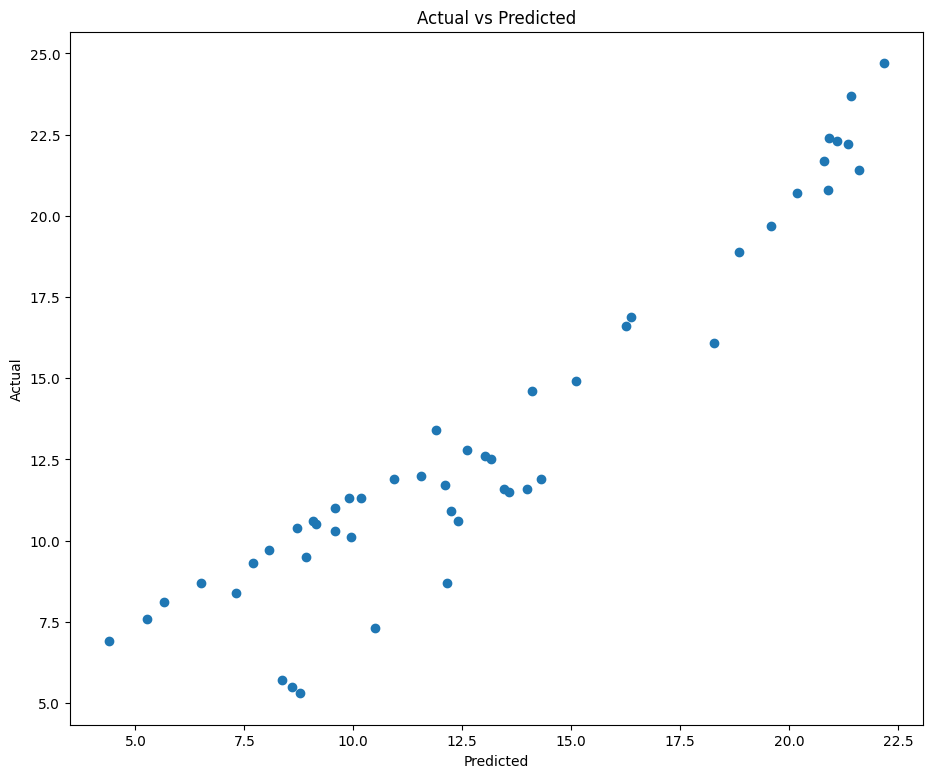

In [83]:
model_results = LinearRegressionModel(X_train[["TV", "Radio", "Newspaper"]], X_test[["TV", "Radio", "Newspaper"]])


cv_score = cross_val_score(LinearRegression(), X[["TV", "Radio", "Newspaper"]], y, cv=10)

print("Cross-Val Results:", cv_score)
print("Cross-Val Mean:", cv_score.mean())
print("Cross-Val Std:", cv_score.std())


 
model_results.update({"PredictorModel/s":"TV , Newspaper & Radio", "Cross-Val Mean": cv_score.mean() * 100})


model_results_df = pd.DataFrame([model_results])

# Now, concatenate the original DataFrame with the new one.
final_result = pd.concat([metric_results, model_results_df], ignore_index=True)

Cross-Val Results: [0.87936561 0.85860496 0.92960574 0.89040105 0.93302554 0.93129743
 0.76486772 0.91373255 0.83925519 0.92951475]
Cross-Val Mean: 0.8869670516810129
Cross-Val Std: 0.051468413387901674


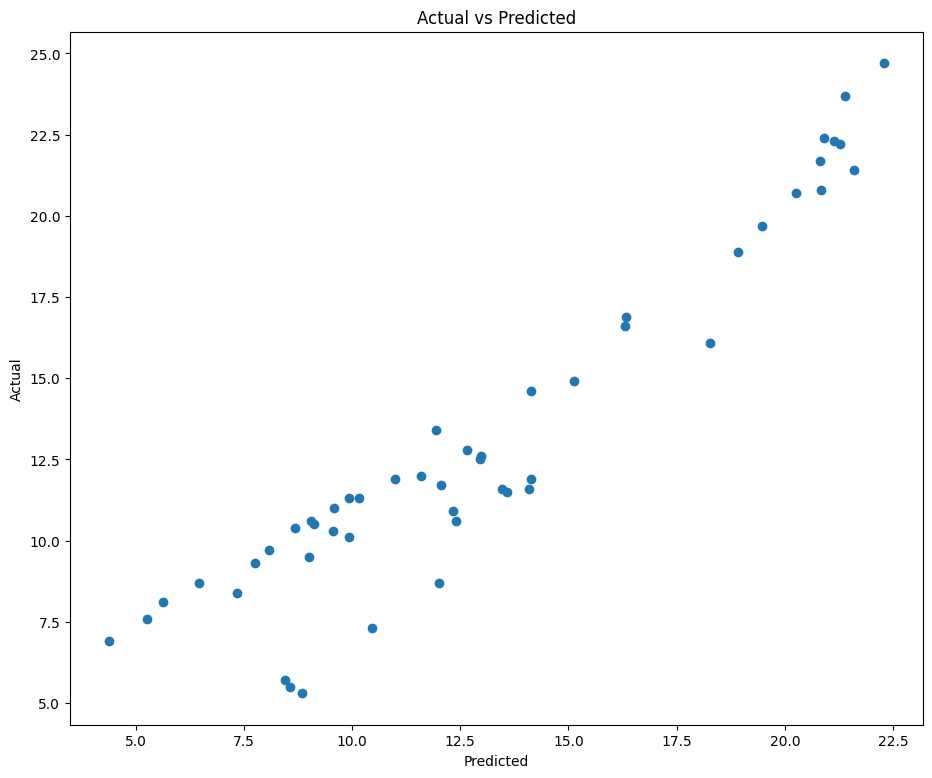

In [80]:
model_results = LinearRegressionModel(X_train[["TV", "Radio" ]], X_test[["TV", "Radio" ]])


cv_score = cross_val_score(LinearRegression(), X[["TV", "Radio" ]], y, cv=10)

print("Cross-Val Results:", cv_score)
print("Cross-Val Mean:", cv_score.mean())
print("Cross-Val Std:", cv_score.std())


 
model_results.update({"PredictorModel/s":"TV & Radio", "Cross-Val Mean": cv_score.mean() * 100})


model_results_df = pd.DataFrame([model_results])

# Now, concatenate the original DataFrame with the new one.
final_result = pd.concat([final_result, model_results_df], ignore_index=True)

Cross-Val Results: [0.70015158 0.43449405 0.58322591 0.78975123 0.47952235 0.62298657
 0.66525353 0.60389703 0.16530872 0.64237498]
Cross-Val Mean: 0.5686965937483904
Cross-Val Std: 0.16552311937395764


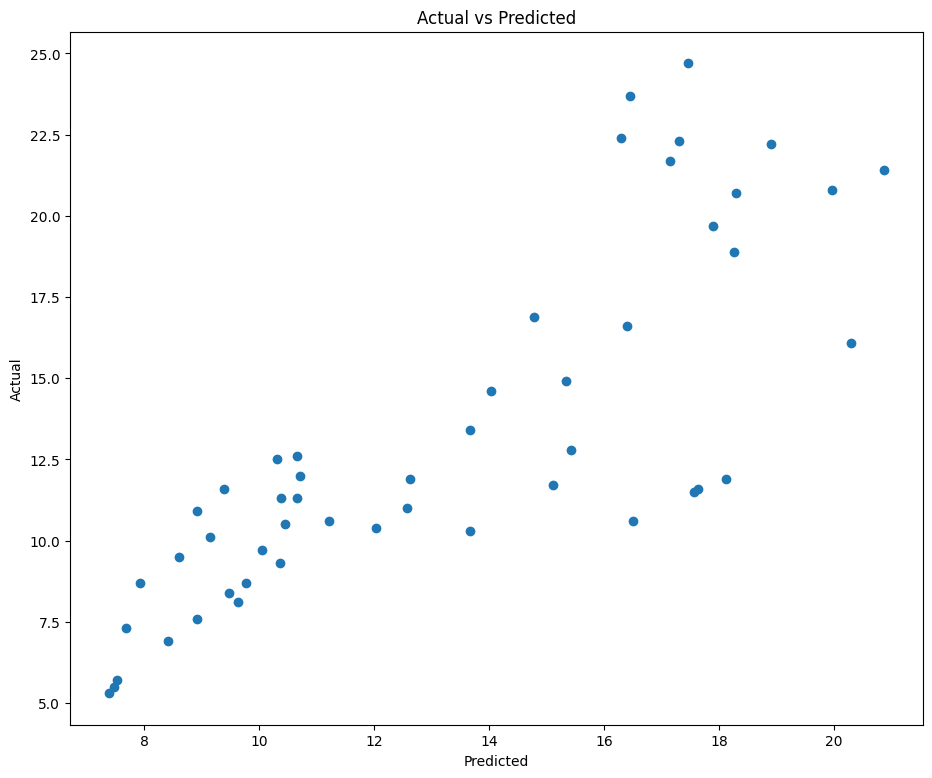

In [55]:
model_results = LinearRegressionModel(X_train[["TV"]], X_test[["TV"]])


cv_score = cross_val_score(LinearRegression(), X[["TV"]], y, cv=10)

print("Cross-Val Results:", cv_score)
print("Cross-Val Mean:", cv_score.mean())
print("Cross-Val Std:", cv_score.std())


 
model_results.update({"PredictorModel/s": "TV", "Cross-Val Mean": cv_score.mean() * 100})


model_results_df = pd.DataFrame([model_results])

# Now, concatenate the original DataFrame with the new one.
final_result = pd.concat([final_result, model_results_df], ignore_index=True)

In [56]:
final_result.set_index('PredictorModel/s', inplace=True)
final_result.head()

,R2,MAE,MSE,RMSE,CrossValScore,Cross-Val Mean
PredictorModel/s,,,,,,
"TV , Newspaper & Radio",89.351633,1.402312,2.880024,1.697063,NaN,88.535622
TV & Radio,89.447871,1.388680,2.853995,1.689377,NaN,88.696705
TV,66.061204,2.273771,9.179299,3.029736,NaN,56.869659


In [59]:
cd "/home/ajeet/Documents/Officials/full-stack-project-portfolio/DataScience/AdvertisingSalesPredictor/model"

/home/ajeet/Documents/Officials/full-stack-project-portfolio/DataScience/AdvertisingSalesPredictor/model


In [60]:
pwd

'/home/ajeet/Documents/Officials/full-stack-project-portfolio/DataScience/AdvertisingSalesPredictor/model'

In [84]:
# load the model
model = joblib.load('ols_model.pkl')
print("Model loaded successfully.")
 
# Example data for prediction
example_data = pd.DataFrame({
    'TV': [150, 200],
    'Radio': [30, 50],
    'Newspaper': [20, 10]
})
predictions = model.predict(example_data)
print("Predictions for example data:", predictions)

Model loaded successfully.
Predictions for example data: [15.38839514 21.46352287]
